In [ ]:
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
       
import torch
import numpy as np
import warp as wp

# Initialize Warp
wp.config.verify_autograd_array_access = False
wp.config.verbose = False
wp.init()

from warpSPHCore import radiusSearchCompactHashMap, sphOperation_warp
from warpSPHCore.enumTypes import *

from warpSPHCore import *

import matplotlib.pyplot as plt
from demo_util import *

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
device = torch.device('cpu')
device = torch.device('cuda')
targetNumNeighbors = 50
nx = 128
dim = 2
numParticles = nx**dim

warpOnly = False
periodic = True

queryPositions, referencePositions, \
        querySupports, referenceSupports, \
        queryMasses, referenceMasses, \
        queryDensities, referenceDensities, \
        domain, adjacency, neighborhood, simulationState, measurements = prepData(nx, targetNumNeighbors, dim, device, periodic, warpOnly)


Module warpSPHCore.radiusSearch.wp_compactHash e2c9126 load on device 'cuda:0' took 2.01 ms  (cached)
Module warpSPHCore.operations.wp_density 414a5a1 load on device 'cuda:0' took 2.08 ms  (cached)


In [3]:
f = torch.randn(numParticles, device=device, dtype=torch.float32)

interpolated_warp = sphOperation_warp(
    queryPositions, referencePositions,
    querySupports, referenceSupports,
    queryMasses, referenceMasses,
    queryDensities, referenceDensities,
    f, f,
    domain = domain, adjacency = adjacency, 
    operation = WarpOperation.Interpolate, operationMode = OperationDirection.AllToAll,
    kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather,
)

if not warpOnly:
    interpolated_diffSPH = SPHOperation(
        simulationState,
        quantity = f,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Interpolate,
        supportScheme = SupportScheme.Gather,
        correctionTerms= [],
        positiveDivergence=False
    )


Module warpSPHCore.operations.wp_interpolate d807e67 load on device 'cuda:0' took 1.99 ms  (cached)


In [ ]:
import warp as wp
from warp.types import vector, matrix
# from wp_tensor import tensor
from typing import Any
import torch
from warpSPHCore import *

from warpSPHCore.kernels import *
from torch.profiler import profile, record_function, ProfilerActivity
from warpSPHCore.enumTypes import *
from typing import Optional

@wp.func
def computeCustom_Func(
    # General Shape Parameters and indices
    i : wp.int32, dim: wp.int32, 

    # SPH properties for the query set (indexed by i)
    queryPositions: wp.array(dtype=vector(dtype = wp.float32, length=Any)), querySupports: wp.array(dtype = wp.float32), queryMasses: wp.array(dtype = wp.float32), queryDensities: wp.array(dtype = wp.float32), queryValues: Any, # type: ignore

    # SPH properties for the reference set (indexed by j in the neighbor loop)
    referencePositions : wp.array(dtype=vector(length=Any, dtype = wp.float32)), referenceSupports : wp.array(dtype = wp.float32), referenceMasses: wp.array(dtype = wp.float32), referenceDensities: wp.array(dtype = wp.float32), referenceValues: Any, # type: ignore
    
    # Domain and kernel parameters
    periodicity : wp.array(dtype = wp.bool), domainMin : wp.array(dtype = wp.float32), domainMax : wp.array(dtype = wp.float32), # type: ignore
    mode_uint: wp.uint32, kernel_int: wp.int32, 
    
    # Operation specific parameters
    gradientMode_int: wp.int32, # type: ignore
    
    # Neighbor list data, pre accessed to avoid gradient issues with dynamic for loops
    neighborList: wp.array(dtype = wp.int64), # type: ignore
    neighborOffset : wp.int32, numNeighs: wp.int32, 
    
    # Indicates if the input quantities have already been scattered to the neighbor level 
    preScatteredQuantities: wp. bool,
    
    # Operation Mode for masking certain kinds of interactions, e.g. for directional operations
    opInt: wp.int32, queryKinds : wp.array(dtype = wp.int32), referenceKinds : wp.array(dtype = wp.int32), # type: ignore

    # Optional Correction Terms:
    # Gradient renormalization matrices for each query point, used for correcting the kernel gradient based on the local particle distribution.
    useGradientRenormalization: wp.bool, queryRenormalizationMatrices: wp.array(dtype = matrix(shape=(Any, Any), dtype=wp.float32)), # type: ignore
    # Grad-h correction terms for each query and reference point, used for correcting the kernel gradient based on the local particle distribution and smoothing length variations.
    useGradHTerms: wp.bool, queryOmegas: wp.array(dtype = wp.float32), referenceOmegas: wp.array(dtype = wp.float32),  # type: ignore
    # Whether to use actual volume (mass/density) or apparent volume for the gradient computation, and the corresponding volumes if needed.
    useVolume: bool, queryVolumes: wp.array(dtype = wp.float32), referenceVolumes: wp.array(dtype = wp.float32), # type: ignore
    # Whether to use CRK kernel correction for the computation, and the corresponding correction terms if needed.
    useCRK: bool, queryA: wp.array(dtype = wp.float32), queryB: wp.array(dtype = vector(length=Any, dtype=wp.float32)), queryGradA: wp.array(dtype=vector(length=Any, dtype=wp.float32)), queryGradB: wp.array(dtype=matrix(shape=(Any, Any), dtype=wp.float32)), # type: ignore
    
    # Custom function parameters begin here

    # Dummy value to allow allocation
    outputValue: Any # type: ignore
):
    if opInt != 0:
        if not checkDirectionality_i(queryKinds[i], opInt):
            return outputValue * 0.0
    # Unpack query point properties
    xi      = queryPositions[i]
    hi      = querySupports[i]
    # mi      = queryMasses[i] # Generally not needed
    rhoi    = queryDensities[i]
    fi      = queryValues[i]
    # Unpack optional correction terms
    if useGradHTerms:
        fi  = queryValues[i] / queryOmegas[i]
    # Unpack optional correction terms
    Li      = queryRenormalizationMatrices[i] if useGradientRenormalization else type(queryRenormalizationMatrices[0])()*0.0
    Ai      = queryA[i] if useCRK else type(queryA[0])(0.0)
    Bi      = queryB[i] if useCRK else type(queryB[0])(0.0)
    gradA_i = queryGradA[i] if useCRK else type(queryGradA[0])(0.0)
    gradB_i = queryGradB[i] if useCRK else type(queryGradB[0])()*0.0
    
    # Initialize the output value
    out     = type(outputValue)(0.0)
    
    # Loop over neighbors to compute the gradient contribution from each neighbor    
    for neighborIndex in range(numNeighs):
        jj = neighborOffset + neighborIndex
        j  = wp.int32(neighborList[jj])
        if opInt != 0:
            if not checkDirectionality_j(referenceKinds[j], opInt):
                continue
        ##########################################################
        #   The core particle-particle interaction starts here   #
        ##########################################################
        
        mj   = referenceMasses[j]
        rhoj = referenceDensities[j]
        apparentVolume = mj / rhoj if not useVolume else referenceVolumes[j]

        fj   = type(fi)(0.0)
        if preScatteredQuantities:
            if useGradHTerms:
                fj = referenceValues[jj] / referenceOmegas[j]
            else:
                fj = referenceValues[jj]
        else:
            if useGradHTerms:
                fj = referenceValues[j] / referenceOmegas[j]
            else:
                fj = referenceValues[j]

        # Custom Functionality begins here

        
        w_ij = computeKernelCRK(
            xi, referencePositions[j], 
            hi, referenceSupports[j], 
            kernel_int, mode_uint, periodicity, domainMin, domainMax,
            useCRK, Ai, Bi
        )

        gradw_ij = computeKernelGradientCRK(
            xi, referencePositions[j], 
            hi, referenceSupports[j],
            kernel_int, mode_uint, periodicity, domainMin, domainMax,
            useCRK, Ai, Bi, gradA_i, gradB_i
        )


        if useGradientRenormalization:
            gradw_ij = matmul(Li, gradw_ij)

        out += apparentVolume * fj * w_ij

    return out

@wp.kernel
def computeCustom_Kernel(
    queryPositions : wp.array(dtype = vector(length=Any, dtype=wp.float32)), referencePositions : wp.array(dtype=vector(length=Any, dtype=wp.float32)), # type: ignore
    querySupports : wp.array(dtype = wp.float32), referenceSupports : wp.array(dtype = wp.float32), # type: ignore
    queryMasses: wp.array(dtype = wp.float32), referenceMasses: wp.array(dtype = wp.float32),  # type: ignore
    queryDensities: wp.array(dtype = wp.float32), referenceDensities: wp.array(dtype = wp.float32), # type: ignore
    queryValues: wp.array(dtype = Any), referenceValues: wp.array(dtype = Any), # type: ignore
    
    domainMin : wp.array(dtype = wp.float32), domainMax : wp.array(dtype = wp.float32), periodicity : wp.array(dtype = wp.bool), # type: ignore
    
    mode_uint: wp.uint32, kernel_int : wp.int32, gradientMode_int: wp.int32,
    neighborList: wp.array(dtype = wp.int64), neighborListRowOffsets: wp.array(dtype = wp.int32), numNeighbors: wp.array(dtype = wp.int32), # type: ignore
    
    preScatteredQuantities: wp. bool,
    
    opInt: wp.int32, queryKinds : wp.array(dtype = wp.int32), referenceKinds : wp.array(dtype = wp.int32), # type: ignore

    useGradientRenormalization: wp.bool, queryRenormalizationMatrices: wp.array(dtype = matrix(shape=(Any, Any), dtype=wp.float32)),# type: ignore
    useGradHTerms: wp.bool, queryOmegas: wp.array(dtype = wp.float32), referenceOmegas: wp.array(dtype = wp.float32),  # type: ignore
    useVolume: wp.bool, queryVolumes: wp.array(dtype = wp.float32), referenceVolumes: wp.array(dtype = wp.float32), # type: ignore
    useCRK: wp.bool, crk_A: wp.array(dtype = wp.float32), crk_B: wp.array(dtype = vector(length=Any, dtype=wp.float32)), crk_gradA: wp.array(dtype = vector(length=Any, dtype=wp.float32)), crk_gradB: wp.array(dtype = matrix(shape=(Any, Any), dtype=wp.float32)), # type: ignore
    
    outputValues : wp.array(dtype = Any) # type: ignore
):                                                                                    
    i = wp.tid()
    if i >= queryPositions.shape[0]:
        return
    
    outputValues[i] = computeCustom_Func(
        i, get_dim(queryPositions), 

        queryPositions, querySupports, queryMasses, queryDensities, queryValues,
        referencePositions, referenceSupports, referenceMasses, referenceDensities, referenceValues,
        
        periodicity, domainMin, domainMax, 
        mode_uint, kernel_int, gradientMode_int,

        neighborList, neighborListRowOffsets[i], numNeighbors[i], 

        preScatteredQuantities,
        
        opInt, queryKinds, referenceKinds,

        useGradientRenormalization, queryRenormalizationMatrices, 
        useGradHTerms, queryOmegas, referenceOmegas, 
        useVolume, queryVolumes, referenceVolumes,
        useCRK, crk_A, crk_B, crk_gradA, crk_gradB,

        type(outputValues[i])(0.0)
    )
    
def computeCustomWarp(
    queryPositions, referencePositions,
    querySupports, referenceSupports,
    queryMasses, referenceMasses,
    queryDensities, referenceDensities,
    queryValues, referenceValues,
    domain: DomainDescription,
    supportMode: SupportScheme,
    kernel: KernelFunctions,    
    operationMode: OperationDirection,
    adjacency: AdjacencyListWarp,

    scatteredQuantities: Optional[torch.Tensor] = None,
    
    queryKinds: Optional[torch.Tensor] = None, referenceKinds: Optional[torch.Tensor] = None,
    useGradientRenormalization: bool = False, renormalizationMatrices: Optional[torch.Tensor] = None,
    useGradHTerms: bool = False, queryOmegas: Optional[torch.Tensor] = None, referenceOmegas: Optional[torch.Tensor] = None,
    useVolume: bool = False, queryVolumes: Optional[torch.Tensor] = None, referenceVolumes: Optional[torch.Tensor] = None,
    useCRK: bool = False, crk_A: Optional[torch.Tensor] = None, crk_B: Optional[torch.Tensor] = None, crk_gradA: Optional[torch.Tensor] = None, crk_gradB: Optional[torch.Tensor] = None
):
    with record_function("warpSPH[CRKVolume]"):
        with record_function("warpSPH[CRKVolume] - Preprocessing"):
            # Preprocessing and input validation
            domainMin = domain.min
            domainMax = domain.max
            periodicity = domain.periodic

            mode_uint = convertModeToUint(supportMode.name)
            kernel_int = kernel.value
            gradientMode_int = 0
            opInt = wp.int32(operationMode.value)

            device = queryPositions.device
            dim = queryPositions.shape[1]

            qK, rK = checkKinds(operationMode, device, queryKinds, referenceKinds)
            preScatteredQuantities, qV, rV = checkQV(queryValues, referenceValues, scatteredQuantities)
            renormalizationMatrices_ = checkInputRenormalization(dim, device, useGradientRenormalization, renormalizationMatrices)
            queryOmegas_, referenceOmegas_ = checkInputGradHTerms(dim, device, useGradHTerms, queryOmegas, referenceOmegas)
            queryVolumes_, referenceVolumes_ = checkInputVolume(dim, device, useVolume, queryVolumes, referenceVolumes)
            crk_A_, crk_B_, crk_gradA_, crk_gradB_ = checkInputCRK(dim, device, useCRK, crk_A, crk_B, crk_gradA, crk_gradB)

            # Warp kernels only support rank-1 (vector) and rank-2 (matrix) field types.
            outputSize = queryPositions.shape[0]
            inputShape = queryPositions.shape[1:]

        with record_function("warpSPH[CRKVolume] - Kernel Execution"):
            warp_result = warpWrapper(
                launch_kernel, computeCustom_Kernel, outputSize, wp.float32,
                queryPositions, referencePositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                queryDensities, referenceDensities,
                qV, rV,

                domainMin, domainMax, periodicity,
                mode_uint, kernel_int, gradientMode_int,
                adjacency.j, adjacency.edgeOffsets, adjacency.numNeighbors, 
                
                preScatteredQuantities,

                opInt, qK, rK,

                wp.bool(useGradientRenormalization), renormalizationMatrices_,
                wp.bool(useGradHTerms), queryOmegas_, referenceOmegas_,
                wp.bool(useVolume), queryVolumes_, referenceVolumes_,
                wp.bool(useCRK), crk_A_, crk_B_, crk_gradA_, crk_gradB_
            )

    return warp_result


In [5]:
customOpOutput = computeCustomWarp(
    queryPositions, referencePositions,
    querySupports, referenceSupports,
    queryMasses, referenceMasses,
    queryDensities, referenceDensities,
    f, f,
    domain = domain, adjacency = adjacency, 
    operationMode = OperationDirection.AllToAll,
    kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather,
)

Module __main__ 1b4728a load on device 'cuda:0' took 2.21 ms  (cached)


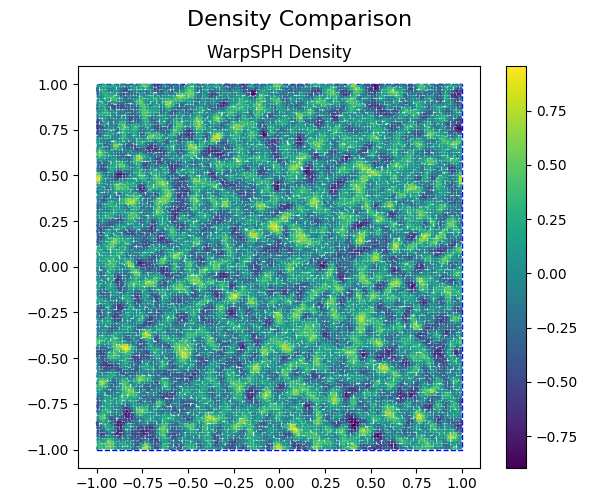

In [6]:
fig, axis = plt.subplots(1,1, figsize = (6, 5), squeeze=False)
markerSize = 8 if warpOnly else 2
gridVisualization = False 
gridResolution = 128

warpPlot = visualizeParticles(
      fig, axis[0,0],
      PlotSet(
        positions = queryPositions,
        supports = querySupports,
        masses = queryMasses,
        densities = queryDensities,
        kinds = torch.zeros(queryPositions.shape[0], dtype = torch.long)
      ),
      quantity = customOpOutput,
      kernel = KernelType.Wendland2,
      domain = domain,

      cmap = 'viridis',
      markerSize = markerSize,
      gridVisualization = gridVisualization,
      gridResolution = gridResolution,

      streamLines = False,
      plotDomain = True,
      title = "WarpSPH Density",
)


fig.suptitle("Density Comparison" if not warpOnly else "WarpSPH Density", fontsize = 16)
fig.tight_layout()
